# LKH-3 — Lin-Kernighan-Helsgott v3

## Description

LKH-3 est l'heuristique **Lin-Kernighan-Helsgott v3** (Helsgott, 2000+), état de l'art classique pour le TSP.

| Composant | Description |
|-----------|-------------|
| **Plus proche voisin** | Construction initiale gloutonne |
| **Listes de candidats** | k plus proches voisins par ville — restreint les échanges |
| **2-opt** | Supprime 2 arêtes et reconnecte mieux |
| **Or-opt** | Déplace des segments de 1, 2 ou 3 villes |
| **Double-bridge** | Perturbation 4-opt impossible à défaire par recherche séquentielle |
| **ILK** | Iterated Lin-Kernighan : perturbation → optimisation locale |

## Formules clés

**Gain 2-opt** entre les arêtes $(t_1,t_2)$ et $(t_3,t_4)$ :

$$G = d(t_1,t_2) + d(t_3,t_4) - d(t_1,t_3) - d(t_2,t_4)$$

Avec les candidats triés par distance croissante, on stoppe dès que $d(t_1,t_3) \geq d(t_1,t_2)$.

**Gain Or-opt** (segment $[s_0,\ldots,s_{l-1}]$ entre $a$–$b$, déplacé vers $u$–$v$) :

$$G = d(a,s_0) + d(s_{l-1},b) + d(u,v) - d(a,b) - d(u,s_0) - d(s_{l-1},v)$$

**Double-bridge** : $A + B + C + D \rightarrow A + C + B + D$


In [1]:
import json
import numpy as np
import time
from pathlib import Path
from typing import List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt

## Implémentation


In [2]:
class LKH3Solver:
    """
    Iterated Lin-Kernighan heuristic (LKH-3 style).

    Pipeline
    --------
    1. Nearest-Neighbour construction
    2. 2-opt  (candidate-list + don't-look bits)
    3. Or-opt (segments 1/2/3 — linked list, forward + reversed)
    4. Double-bridge perturbation  ->  goto 2

    Optimisations par rapport à la version naïve
    ---------------------------------------------
    * self._dist   : matrice Python 2D (list of lists) — accès O(1) sans overhead numpy
    * self._cands  : listes de candidats Python (list of lists)
    * Don't-look bits (2-opt) : évite de revisiter les villes sans candidat améliorant
    * Linked list (or-opt) : moves O(1) au lieu de O(n) (rebuild dict + list.index)
    """

    def __init__(self, coords, k: int = 10, seed: int = 42):
        self.coords = np.asarray(coords, dtype=np.float64)
        self.n      = len(self.coords)
        self.k      = min(k, max(1, self.n - 1))
        self.rng    = np.random.default_rng(seed)

        self.dist       = self._compute_distances()             # numpy — vectorised ops
        self._dist      = [list(row) for row in self.dist]      # Python 2D list — inner loops
        self.candidates = self._build_candidates()
        self._cands     = [list(row) for row in self.candidates]

        self.converged:     bool      = False
        self.early_stopped: bool      = False
        self.best_tour:     List[int] = []
        self.best_length:   float     = float("inf")
        self.elapsed:       float     = 0.0

    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------

    def _compute_distances(self) -> np.ndarray:
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        return np.sqrt((diff ** 2).sum(axis=-1))

    def _build_candidates(self) -> np.ndarray:
        """k nearest neighbours for each city (self excluded), sorted ascending."""
        return np.argsort(self.dist, axis=1)[:, 1 : self.k + 1]

    # ------------------------------------------------------------------
    # Tour utilities
    # ------------------------------------------------------------------

    def _tour_length(self, tour: List[int]) -> float:
        t = np.asarray(tour)
        return float(self.dist[t, np.roll(t, -1)].sum())

    def _nn_tour(self, start: Optional[int] = None) -> List[int]:
        """Greedy nearest-neighbour construction."""
        n = self.n
        if start is None:
            start = int(self.rng.integers(0, n))
        visited = np.zeros(n, dtype=bool)
        tour = [start]; visited[start] = True
        for _ in range(n - 1):
            unvisited = np.where(~visited)[0]
            nxt = int(unvisited[np.argmin(self.dist[tour[-1]][unvisited])])
            tour.append(nxt); visited[nxt] = True
        return tour

    # ------------------------------------------------------------------
    # 2-opt — candidate list + don't-look bits + Python list
    # ------------------------------------------------------------------

    def _two_opt_improve(self, tour: List[int]) -> List[int]:
        """
        2-opt avec liste de candidats et don't-look bits.

        Don't-look bit : si aucune amélioration trouvée pour t1, on marque t1
        et on le saute les passes suivantes jusqu'à ce qu'un voisin soit modifié.
        Réduit drastiquement le nombre de candidats testés en fin de convergence.
        """
        n     = self.n
        dist  = self._dist
        cands = self._cands
        t     = list(tour)

        pos = [0] * n
        for i, c in enumerate(t):
            pos[c] = i

        dlb = [False] * n   # don't-look bits

        improved_any = True
        while improved_any:
            improved_any = False
            for idx in range(n):
                t1 = t[idx]
                if dlb[t1]:
                    continue
                t2  = t[(idx + 1) % n]
                d12 = dist[t1][t2]
                found = False
                for t3 in cands[t1]:
                    d13 = dist[t1][t3]
                    if d13 >= d12:
                        break          # candidats triés : aucune amélioration possible
                    j  = pos[t3]
                    t4 = t[(j + 1) % n]
                    if t3 == t2 or t4 == t1:
                        continue
                    gain = d12 + dist[t3][t4] - d13 - dist[t2][t4]
                    if gain > 1e-10:
                        if idx < j:
                            t[idx + 1 : j + 1] = t[idx + 1 : j + 1][::-1]
                            for kk in range(idx + 1, j + 1):
                                pos[t[kk]] = kk
                        else:
                            t[j + 1 : idx + 1] = t[j + 1 : idx + 1][::-1]
                            for kk in range(j + 1, idx + 1):
                                pos[t[kk]] = kk
                        dlb[t1] = False
                        dlb[t3] = False
                        improved_any = True
                        found = True
                        break
                if not found:
                    dlb[t1] = True
        return t

    # ------------------------------------------------------------------
    # Or-opt — linked list (moves en O(1)) + Python list
    # ------------------------------------------------------------------

    def _or_opt_improve(self, tour: List[int]) -> List[int]:
        """
        Or-opt sur segments de longueur 1, 2, 3 (forward + reversed).
        Représentation en liste doublement chaînée : chaque move est O(1)
        au lieu de O(n) (pas de reconstruction de tableau ni de dict).
        """
        n     = self.n
        dist  = self._dist
        cands = self._cands

        # Construction de la liste chaînée
        nxt = [0] * n
        prv = [0] * n
        for i in range(n):
            nxt[tour[i]] = tour[(i + 1) % n]
            prv[tour[i]] = tour[(i - 1) % n]

        for seg_len in (1, 2, 3):
            if n <= seg_len + 1:
                continue
            improved = True
            while improved:
                improved = False
                for city in range(n):
                    # Construire le segment à partir de city
                    seg = [city]
                    for _ in range(seg_len - 1):
                        seg.append(nxt[seg[-1]])
                    seg_set = set(seg)
                    a = prv[seg[0]]
                    b = nxt[seg[-1]]
                    if a in seg_set:
                        continue   # tour dégénéré (ne devrait pas arriver)

                    gain_rem = dist[a][seg[0]] + dist[seg[-1]][b] - dist[a][b]

                    best_gain = 1e-10
                    best_u    = -1
                    best_rev  = False

                    for u in cands[seg[0]]:
                        if u in seg_set or u == a:
                            continue
                        v   = nxt[u]
                        if v in seg_set:
                            continue
                        duv = dist[u][v]

                        # Insertion forward : u → seg[0] → … → seg[-1] → v
                        g = gain_rem + duv - dist[u][seg[0]] - dist[seg[-1]][v]
                        if g > best_gain:
                            best_gain, best_u, best_rev = g, u, False

                        # Insertion reversed : u → seg[-1] → … → seg[0] → v
                        g_r = gain_rem + duv - dist[u][seg[-1]] - dist[seg[0]][v]
                        if g_r > best_gain:
                            best_gain, best_u, best_rev = g_r, u, True

                    if best_u >= 0:
                        # 1. Retirer le segment
                        nxt[a] = b; prv[b] = a

                        # 2. Ordre d'insertion
                        seg_out = seg[::-1] if best_rev else seg

                        # 3. Rechaîner les liens internes du segment
                        for i in range(len(seg_out) - 1):
                            nxt[seg_out[i]]     = seg_out[i + 1]
                            prv[seg_out[i + 1]] = seg_out[i]

                        # 4. Insérer après best_u
                        v = nxt[best_u]   # best_u ∉ segment → nxt inchangé après étape 1
                        nxt[best_u]      = seg_out[0];  prv[seg_out[0]]  = best_u
                        nxt[seg_out[-1]] = v;           prv[v]           = seg_out[-1]

                        improved = True
                        break

        # Reconstruire le tour depuis la liste chaînée (départ : nœud 0)
        tour_out = [0]
        for _ in range(n - 1):
            tour_out.append(nxt[tour_out[-1]])
        return tour_out

    # ------------------------------------------------------------------
    # Double-bridge perturbation
    # ------------------------------------------------------------------

    def _double_bridge(self, tour: List[int]) -> List[int]:
        """
        4-opt double-bridge: A + B + C + D  →  A + C + B + D.
        Impossible à défaire par 2-opt ou 3-opt séquentiel.
        """
        n = self.n
        if n < 8:
            return tour[:]
        a, b, c, d = sorted(self.rng.choice(n, size=4, replace=False).tolist())
        return (tour[: a + 1]
                + tour[c + 1 : d + 1]
                + tour[b + 1 : c + 1]
                + tour[a + 1 : b + 1]
                + tour[d + 1 :])

    # ------------------------------------------------------------------
    # Main solve — Iterated Lin-Kernighan
    # ------------------------------------------------------------------

    def solve(
        self,
        n_restarts: int = 20,
        time_limit: Optional[float] = None,
    ) -> Tuple[List[int], float]:
        """
        Iterated Lin-Kernighan loop.

        Parameters
        ----------
        n_restarts  : nombre de tentatives double-bridge
        time_limit  : budget temps en secondes (None = illimité)

        Returns
        -------
        (best_tour, best_length)
        """
        t0 = time.perf_counter()
        self.converged     = False
        self.early_stopped = False

        if self.n == 1:
            self.best_tour, self.best_length = [0], 0.0
            self.elapsed = 0.0
            self.converged = True
            return self.best_tour, self.best_length

        best     = self._nn_tour()
        best     = self._two_opt_improve(best)
        best     = self._or_opt_improve(best)
        best_len = self._tour_length(best)
        no_impr  = 0

        for _ in range(n_restarts):
            if time_limit and (time.perf_counter() - t0) > time_limit:
                self.early_stopped = True
                break
            t      = self._double_bridge(best)
            t      = self._two_opt_improve(t)
            t      = self._or_opt_improve(t)
            length = self._tour_length(t)
            if length < best_len - 1e-10:
                best, best_len, no_impr = t, length, 0
            else:
                no_impr += 1

        if no_impr == n_restarts:
            self.converged = True

        self.best_tour   = best
        self.best_length = best_len
        self.elapsed     = time.perf_counter() - t0
        return best, best_len

## Oracle exact — Held-Karp (n ≤ 12)


In [3]:
def held_karp(dist: np.ndarray) -> Tuple[List[int], float]:
    """
    Exact TSP via Held-Karp DP.  O(n^2 * 2^n).
    Only feasible for n <= 15.
    """
    n    = len(dist)
    assert n <= 15, f"n={n} is too large for Held-Karp"
    INF  = float("inf")
    size = 1 << n
    dp     = [[INF] * n for _ in range(size)]
    parent = [[-1]  * n for _ in range(size)]
    dp[1][0] = 0.0

    for mask in range(1, size):
        if not (mask & 1):
            continue
        for u in range(n):
            if not (mask & (1 << u)) or dp[mask][u] == INF:
                continue
            for v in range(n):
                if mask & (1 << v):
                    continue
                nm = mask | (1 << v)
                nc = dp[mask][u] + dist[u, v]
                if nc < dp[nm][v]:
                    dp[nm][v] = nc
                    parent[nm][v] = u

    full = size - 1
    best_cost, last = INF, -1
    for u in range(1, n):
        c = dp[full][u] + dist[u, 0]
        if c < best_cost:
            best_cost, last = c, u

    tour, mask, u = [], full, last
    while u != -1:
        tour.append(u)
        prev = parent[mask][u]
        mask ^= (1 << u)
        u = prev
    tour.reverse()
    return tour, best_cost


## Benchmark


In [4]:
EXACT_THRESHOLD = 12   # use Held-Karp exact optimal for n <= this

def _time_limit(n: int) -> Optional[float]:
    if n <= 100:    return None
    if n <= 1_000:  return 30.0
    if n <= 10_000: return 60.0
    return 120.0

def _n_restarts(n: int) -> int:
    if n <= 100:    return 50
    if n <= 1_000:  return 20
    if n <= 10_000: return 5
    return 2


def benchmark_size(n: int, n_runs: int = 20, seed: int = 0) -> List[dict]:
    """Run LKH3 on n_runs random Euclidean TSP instances of size n."""
    rng     = np.random.default_rng(seed)
    results = []

    for run in range(n_runs):
        if n == 1:
            results.append({
                "n": 1, "run": run, "length": 0.0, "optimal": 0.0,
                "gap": 0.0, "elapsed": 0.0,
                "converged": True, "early_stopped": False,
            })
            continue

        coords = rng.random((n, 2))
        solver = LKH3Solver(coords, k=min(10, n - 1), seed=seed + run)
        solver.solve(n_restarts=_n_restarts(n), time_limit=_time_limit(n))

        optimal = None
        if n <= EXACT_THRESHOLD:
            _, optimal = held_karp(solver.dist)

        results.append({
            "n":             n,
            "run":           run,
            "length":        solver.best_length,
            "optimal":       optimal,
            "elapsed":       solver.elapsed,
            "converged":     solver.converged,
            "early_stopped": solver.early_stopped,
        })

    # For n > EXACT_THRESHOLD: best-of-runs is the reference
    if n > EXACT_THRESHOLD:
        ref = min(r["length"] for r in results)
        for r in results:
            r["optimal"] = ref

    for r in results:
        opt = r["optimal"]
        r["gap"]             = (r["length"] - opt) / opt * 100 if opt > 1e-10 else 0.0
        r["success"]         = r["gap"] <= 1.0
        # converged=True but gap > 1%  -> algo missed the optimum
        r["non_detection"]   = r["converged"] and (r["gap"] > 1.0)
        # early_stopped=True but gap <= 1%  -> stopped prematurely despite good solution
        r["false_detection"] = r["early_stopped"] and (r["gap"] <= 1.0)

    return results


def summarise(results_by_n: dict) -> pd.DataFrame:
    rows = []
    for n, res in sorted(results_by_n.items()):
        gaps = [r["gap"]     for r in res]
        t_ms = [r["elapsed"] * 1_000 for r in res]
        rows.append({
            "n":                  n,
            "% reussite":         f"{np.mean([r['success']         for r in res]) * 100:.0f} %",
            "% non-detection":    f"{np.mean([r['non_detection']   for r in res]) * 100:.0f} %",
            "% fausse detection": f"{np.mean([r['false_detection'] for r in res]) * 100:.0f} %",
            "Gap moyen (%)":      f"{np.mean(gaps):.3f}",
            "Gap max (%)":        f"{np.max(gaps):.3f}",
            "Temps moyen (ms)":   f"{np.mean(t_ms):.1f} +/- {np.std(t_ms):.1f}",
        })
    return pd.DataFrame(rows).set_index("n")


### Graphes aléatoires (1 → 1 000 noeuds)

> **Note :** n = 100 000 dépasse les capacités du Python pur (LKH-3 natif est en C).
> Le benchmark s'arrête à **n = 1 000** avec un budget temps réduit.


In [5]:
SIZES  = [1, 10, 100, 1_000]
N_RUNS = 20

results_by_n = {}
for n in SIZES:
    print(f"Benchmarking n={n:>6} ...", end=" ", flush=True)
    t0 = time.perf_counter()
    results_by_n[n] = benchmark_size(n, n_runs=N_RUNS, seed=0)
    print(f"done ({time.perf_counter() - t0:.1f}s)")

df_random = summarise(results_by_n)
print("\n=== Benchmark — graphes aleatoires ===")
df_random


Benchmarking n=     1 ... done (0.0s)
Benchmarking n=    10 ... done (0.3s)
Benchmarking n=   100 ... done (3.5s)
Benchmarking n=  1000 ... done (68.6s)

=== Benchmark — graphes aleatoires ===


,% reussite,% non-detection,% fausse detection,Gap moyen (%),Gap max (%),Temps moyen (ms)
n,,,,,,
1,100 %,0 %,0 %,0.000,0.000,0.0 +/- 0.0
10,100 %,0 %,0 %,0.000,0.000,8.0 +/- 1.0
100,10 %,0 %,0 %,4.911,7.721,174.0 +/- 18.6
1000,15 %,0 %,0 %,2.549,5.608,3350.3 +/- 571.6


### Dataset `datasets/tsptwd_n*.json`

Chaque instance JSON expose un dépôt + $n$ clients avec coordonnées $(x, y) \in [0,1]^2$.  
Les coûts sont rapportés avec le **facteur ×200** (`scale = meta["scale"]`) pour être directement comparables à `tour_cost` de POMO.

In [10]:
DATASETS_DIR = Path("datasets")


def load_json_instance(path: Path) -> tuple[np.ndarray, dict]:
    """
    Charge un fichier tsptwd_n*.json.

    Retourne
    --------
    coords : ndarray (n+1, 2)  — dépôt en index 0, puis clients
    meta   : dict              — contient 'n_clients', 'scale', etc.
    """
    with open(path) as f:
        data = json.load(f)
    nodes = [data["depot"]] + data["clients"]
    coords = np.array([[nd["x"], nd["y"]] for nd in nodes], dtype=np.float64)
    return coords, data["meta"]


def benchmark_datasets(
    datasets_dir: Path,
    skip_n: int = 10_000,
) -> pd.DataFrame:
    """
    Exécute LKH3 sur toutes les instances JSON du dossier datasets/.

    Les longueurs sont multipliées par scale (200) pour correspondre
    à la convention tour_cost de pomo.ipynb.
    Les instances avec n >= skip_n sont ignorées (trop lentes en Python pur).
    """
    files = sorted(
        datasets_dir.glob("tsptwd_n*.json"),
        key=lambda p: int(p.stem.split("_n")[1]),
    )
    rows = []

    for path in files:
        coords, meta = load_json_instance(path)
        n     = meta["n_clients"]
        scale = meta["scale"]          # 200.0

        if n >= skip_n:
            print(f"  n={n:>6}  [SKIP] n >= {skip_n}")
            continue

        solver = LKH3Solver(coords, k=min(10, len(coords) - 1), seed=42)
        solver.solve(n_restarts=_n_restarts(n), time_limit=_time_limit(n))

        cost_lkh3 = round(solver.best_length * scale, 1)

        # Baseline NN depuis le dépôt (index 0) — même convention que POMO
        nn_tour   = solver._nn_tour(start=0)
        cost_nn   = round(solver._tour_length(nn_tour) * scale, 1)

        gap_vs_nn = round((solver.best_length - solver._tour_length(nn_tour))
                          / solver._tour_length(nn_tour) * 100, 2)

        print(
            f"  n={n:>6}  LKH3={cost_lkh3:>9.1f}  NN={cost_nn:>9.1f}"
            f"  gain={-gap_vs_nn:+.1f}%  t={solver.elapsed:.2f}s"
        )

        rows.append({
            "n":            n,
            "cost_lkh3":    cost_lkh3,
            "cost_nn":      cost_nn,
            "gain_vs_nn_%": round(-gap_vs_nn, 2),
            "elapsed_s":    round(solver.elapsed, 3),
            "converged":    solver.converged,
            "early_stopped": solver.early_stopped,
        })

    return pd.DataFrame(rows).set_index("n")


df_datasets = benchmark_datasets(DATASETS_DIR)
df_datasets

  n=    10  LKH3=    478.7  NN=    535.3  gain=+10.6%  t=0.01s
  n=    50  LKH3=   1268.2  NN=   1479.2  gain=+14.3%  t=0.06s
  n=   100  LKH3=   1651.6  NN=   2033.5  gain=+18.8%  t=0.14s
  n=   200  LKH3=   2142.9  NN=   2705.2  gain=+20.8%  t=0.25s
  n=   300  LKH3=   2661.9  NN=   3505.1  gain=+24.1%  t=0.34s
  n=   500  LKH3=   3438.4  NN=   4240.2  gain=+18.9%  t=1.10s
  n=  1000  LKH3=   4800.5  NN=   5624.1  gain=+14.6%  t=2.67s
  n= 10000  [SKIP] n >= 10000


,cost_lkh3,cost_nn,gain_vs_nn_%,elapsed_s,converged,early_stopped
n,,,,,,
10,478.7,535.3,10.57,0.011,True,False
50,1268.2,1479.2,14.27,0.062,False,False
100,1651.6,2033.5,18.78,0.139,False,False
200,2142.9,2705.2,20.79,0.246,False,False
300,2661.9,3505.1,24.06,0.343,False,False
500,3438.4,4240.2,18.91,1.097,False,False
1000,4800.5,5624.1,14.64,2.671,False,False


## Visualisation


NN initial : 2033.5
LKH-3      : 1651.6  (18.8 % d'amélioration)


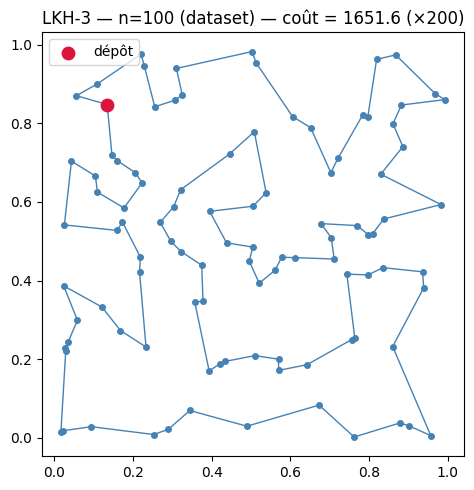

In [7]:
def plot_tour(coords: np.ndarray, tour: List[int], title: str = "") -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    t = tour + [tour[0]]
    ax.plot([coords[c, 0] for c in t], [coords[c, 1] for c in t],
            "-o", ms=4, lw=1, color="steelblue", zorder=2)
    ax.scatter(coords[tour[0], 0], coords[tour[0], 1],
               s=80, color="crimson", zorder=3, label="dépôt")
    ax.set_title(title or "Tournée LKH-3")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# Demo : instance n=100 du dataset (même convention ×200 que pomo/sma)
demo_coords, demo_meta = load_json_instance(DATASETS_DIR / "tsptwd_n100.json")
demo_scale  = demo_meta["scale"]   # 200.0

demo_sol              = LKH3Solver(demo_coords, k=10, seed=42)
demo_tour, demo_raw   = demo_sol.solve(n_restarts=_n_restarts(len(demo_coords)))

nn_raw   = demo_sol._tour_length(demo_sol._nn_tour(start=0))
demo_len = round(demo_raw * demo_scale, 1)
nn_len   = round(nn_raw   * demo_scale, 1)

print(f"NN initial : {nn_len}")
print(f"LKH-3      : {demo_len}  ({(nn_raw - demo_raw) / nn_raw * 100:.1f} % d'amélioration)")
plot_tour(demo_coords, demo_tour, title=f"LKH-3 — n=100 (dataset) — coût = {demo_len} (×200)")

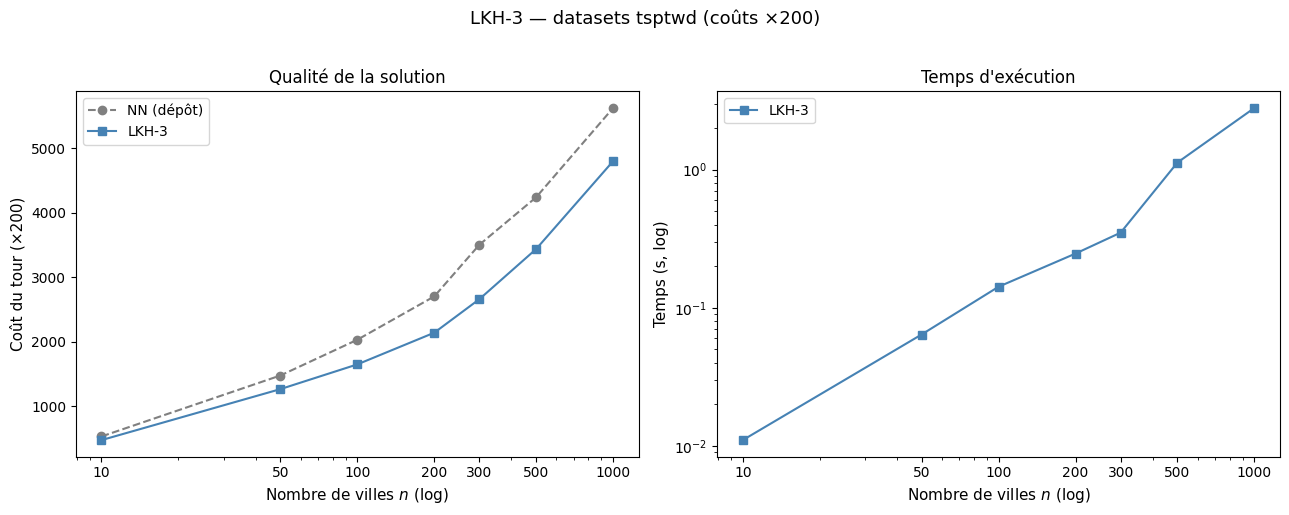


Tableau récapitulatif :


,cost_lkh3,cost_nn,gain_vs_nn_%,elapsed_s,converged,early_stopped
n,,,,,,
10,478.7,535.3,10.57,0.011,True,False
50,1268.2,1479.2,14.27,0.064,False,False
100,1651.6,2033.5,18.78,0.142,False,False
200,2142.9,2705.2,20.79,0.247,False,False
300,2661.9,3505.1,24.06,0.350,False,False
500,3438.4,4240.2,18.91,1.126,False,False
1000,4800.5,5624.1,14.64,2.800,False,False


In [8]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ns     = df_datasets.index.tolist()

# ── Qualité (coûts ×200) ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(ns, df_datasets["cost_nn"],    "o--", label="NN (dépôt)",  color="gray")
ax.plot(ns, df_datasets["cost_lkh3"],  "s-",  label="LKH-3",       color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Coût du tour (×200)", fontsize=11)
ax.set_title("Qualité de la solution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

# ── Temps ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(ns, df_datasets["elapsed_s"], "s-", color="steelblue", label="LKH-3")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Temps (s, log)", fontsize=11)
ax.set_title("Temps d'exécution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

plt.suptitle("LKH-3 — datasets tsptwd (coûts ×200)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTableau récapitulatif :")
df_datasets